# Type B — Futures Funded-Continuation Recovery Hedge

**Asset class:** Futures (ES, NQ, etc.)  
**Hedge Type:** Hedge through eval, get funded, **keep hedging at funded**.  
The funded-stage hedge is sized so that if the funded account fails, the hedge recovers the full cost stack.

**Goal:** Challenge costs become recoverable capital, not sunk costs.

## EV Formula

$$\text{EV}_B = \text{expected funded withdrawals} - \text{expected hedge drag}$$

## Futures-Specific Constraints

| Constraint | Impact on Type B |
|-----------|------------------|
| **Trailing DD** | Higher challenge cost → bigger funded hedge → more drag |
| **Consistency rule (funded)** | Some firms apply consistency at funded stage too |
| **Payout cap** | Limits withdrawal per cycle → slower cost recovery |
| **Activation fee** | Adds to the insured stack that must be recovered |

## Key Question

> "If I keep hedging the funded account, can I treat my challenge costs as recoverable capital rather than sunk capital?"

---

**Reference:** [futures-hedge-model.md](../../directives/Business/futures-hedge-model.md)

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET_PCT   = 0.06
SPREAD_PER_CONTRACT = 5.00
CONSISTENCY_THRESHOLD = 0.20

# ── Type B funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04   # 4% withdrawal per cycle
FUNDED_CYCLES = 6              # cycles modelled
FUNDED_SURVIVAL_RATE = 0.80    # survival prob per cycle
FUNDED_HEDGE_DRAG_PCT = 0.015  # hedge drag per cycle (% of account)

print("Type B Futures notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET_PCT*100:.0f}%, spread=${SPREAD_PER_CONTRACT}/contract")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")

Type B Futures notebook ready.
Challenge: funded_target=6%, spread=$5.0/contract
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle


## 1 — Load & Normalise Futures Data

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_futures_*.json"))
if not json_files:
    raise FileNotFoundError("No futures data found.")

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges_raw = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges_raw)} raw futures challenges")


def parse_dollar(val):
    if isinstance(val, (int, float)): return float(val)
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val).replace(',', ''))
    return float(cleaned) if cleaned else 0.0

def parse_pct(val):
    if isinstance(val, (int, float)): return float(val) if val > 1 else val * 100
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    return float(cleaned) if cleaned else 0.0

def parse_consistency(val):
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    if cleaned:
        pct = float(cleaned)
        return pct / 100.0 if pct > 1 else pct
    return 0.0

def classify_dd_type(val):
    if not val: return "trailing"
    v = str(val).lower()
    if "trail" in v: return "trailing"
    if "static" in v or "balance" in v: return "static"
    return "trailing"

def normalise_challenge(c):
    fee = parse_dollar(c.get('fee_assumed') or c.get('fee_original') or c.get('fee_discounted') or 0)
    activation = parse_dollar(c.get('activation_fee', 0))
    profit_target = parse_dollar(c.get('profit_target', 0))
    if profit_target == 0 and c.get('profit_targets'):
        targets = c['profit_targets']
        if isinstance(targets, list) and targets:
            profit_target = sum(parse_dollar(t) for t in targets)
    max_loss = parse_dollar(c.get('max_loss') or c.get('max_drawdown_pct', 0))
    account_size = parse_dollar(c.get('account_size', 0))
    split = parse_pct(c.get('profit_split_pct') or c.get('profit_split', 80)) / 100.0
    payout_cap = parse_dollar(c.get('max_payout_amount', 0))
    min_threshold = parse_dollar(c.get('min_payout_threshold', 0))
    dd_type = classify_dd_type(c.get('max_loss_type', ''))
    cr = c.get('consistency_rule', {})
    if isinstance(cr, dict):
        consistency_eval = parse_consistency(cr.get('eval', 'None'))
        consistency_funded = parse_consistency(cr.get('funded', 'None'))
    else:
        consistency_eval = parse_consistency(c.get('consistency_rule_eval', 'None'))
        consistency_funded = parse_consistency(c.get('consistency_rule_funded', 'None'))
    mc = c.get('max_contract_size', c.get('max_contracts_minis', 0))
    if isinstance(mc, dict): minis = int(mc.get('minis', 0) or 0)
    elif isinstance(mc, str): nums = re.findall(r'\d+', mc); minis = int(nums[0]) if nums else 0
    else: minis = int(mc) if mc else 0
    return {
        'firm': c.get('firm', 'Unknown'), 'account_size': account_size,
        'steps': int(c.get('steps', 1) if c.get('steps') else 1),
        'fee': fee, 'activation_fee': activation,
        'profit_target': profit_target, 'max_loss': max_loss,
        'dd_type': dd_type, 'profit_split': split,
        'max_contracts_minis': minis, 'payout_cap': payout_cap,
        'min_payout_threshold': min_threshold,
        'consistency_eval': consistency_eval,
        'consistency_funded': consistency_funded,
    }

parsed = [normalise_challenge(c) for c in challenges_raw]
print(f"Parsed {len(parsed)} futures challenges")
print(f"Account sizes: {sorted(set(ch['account_size'] for ch in parsed))}")

Loading: propmatch_futures_20260324_231245.json
Loaded 76 raw futures challenges
Parsed 76 futures challenges
Account sizes: [25000.0, 50000.0, 75000.0, 100000.0, 150000.0, 200000.0, 300000.0]


## 2 — Type B Model: Challenge Phase + Funded Continuation

### How Type B extends Type A

Type A stops at funding. Type B continues:

1. **Challenge phase** — identical to Type A. Trailing DD compounding.
2. **Funded phase** — hedge continues. Each withdrawal cycle:
   - You withdraw profits (capped by payout cap)
   - The hedge absorbs drag
   - The insured stack keeps growing by the drag amount
   - If funded fails → hedge recovers full stack

### The key insight

Challenge costs are **not sunk**. The funded hedge carries the cost stack forward,
recovering it if the funded account eventually fails.

In [3]:
def compute_type_a_cost_futures(ch, funded_target_pct=FUNDED_TARGET_PCT,
                                spread_per_contract=SPREAD_PER_CONTRACT):
    """Challenge-phase cost stack (Type A baseline for futures)."""
    S = ch['account_size']; fee = ch['fee']; act_fee = ch['activation_fee']
    target = ch['profit_target']; DD = ch['max_loss']
    split = ch['profit_split']; dd_type = ch['dd_type']
    minis = ch['max_contracts_minis'] or 1
    cap = ch['payout_cap']; threshold = ch['consistency_eval']; steps = ch['steps']
    if S <= 0 or DD <= 0 or target <= 0: return None

    min_days = math.ceil(1.0 / threshold) if threshold > 0 else 1
    N = max(min_days, 10)
    L = fee
    for step in range(steps):
        step_target = target / steps
        daily_move = step_target / N
        if dd_type == 'trailing':
            for _ in range(N):
                L += daily_move * L / DD + minis * spread_per_contract * 2
        else:
            L += target * L / DD + minis * spread_per_contract * 2 * N
    total_cost = L + act_fee
    return {
        'firm': ch['firm'], 'account_size': S, 'fee': round(fee, 2),
        'activation_fee': round(act_fee, 2), 'steps': steps,
        'dd_type': dd_type, 'dd_max': DD, 'split': split,
        'payout_cap': cap, 'minis': minis,
        'challenge_cost': round(total_cost, 2),
    }


def compute_type_b_futures(ch,
                           funded_target_pct=FUNDED_TARGET_PCT,
                           spread_per_contract=SPREAD_PER_CONTRACT,
                           withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                           n_cycles=FUNDED_CYCLES,
                           survival_rate=FUNDED_SURVIVAL_RATE,
                           hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT):
    """
    Type B Futures: Funded-Continuation Recovery Hedge.
    Challenge costs are recoverable. Funded hedge sized to recover full cost stack.
    """
    base = compute_type_a_cost_futures(ch, funded_target_pct, spread_per_contract)
    if base is None: return None
    S = base['account_size']; split = base['split']; DD = base['dd_max']
    L = base['challenge_cost']; cap = base['payout_cap']

    total_withdrawals = 0.0; total_drag = 0.0
    cycle_details = []; cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        prob_alive = cum_survival
        # Withdrawal (respect payout cap)
        raw_withdrawal = S * withdrawal_pct * split
        withdrawal = min(raw_withdrawal, cap) if cap > 0 else raw_withdrawal
        exp_withdrawal = withdrawal * prob_alive
        # Drag
        drag = S * hedge_drag_pct
        exp_drag = drag * prob_alive
        L_cycle_start = L; L += drag
        # Failure
        prob_fail = prob_alive * (1 - survival_rate)
        exp_recovery = L * prob_fail
        # Capital
        hedge_size = L / DD if DD > 0 else 0
        margin = hedge_size / 100; buffer = hedge_size * DD * 1.5
        capital = margin + buffer

        total_withdrawals += exp_withdrawal; total_drag += exp_drag
        cycle_details.append({
            'cycle': k, 'prob_alive': round(prob_alive, 4),
            'insured_stack': round(L_cycle_start, 2),
            'withdrawal': round(withdrawal, 2),
            'exp_withdrawal': round(exp_withdrawal, 2),
            'drag': round(drag, 2), 'exp_drag': round(exp_drag, 2),
            'prob_fail': round(prob_fail, 4),
            'exp_recovery': round(exp_recovery, 2),
            'capital_funded': round(capital, 2),
        })
        cum_survival *= survival_rate

    # Type A comparison
    type_a_payout = S * funded_target_pct * split
    if cap > 0: type_a_payout = min(type_a_payout, cap)
    type_a_ev = type_a_payout - base['challenge_cost']
    ev_b = total_withdrawals - total_drag
    max_capital = max(c['capital_funded'] for c in cycle_details) if cycle_details else 0

    return {
        'firm': base['firm'], 'account_size': S, 'fee': base['fee'],
        'activation_fee': base['activation_fee'], 'steps': base['steps'],
        'dd_type': base['dd_type'], 'payout_cap': round(cap, 2),
        'challenge_cost': base['challenge_cost'],
        'type_a_ev': round(type_a_ev, 2),
        'total_withdrawals': round(total_withdrawals, 2),
        'total_drag': round(total_drag, 2),
        'ev': round(ev_b, 2),
        'ev_advantage': round(ev_b - type_a_ev, 2),
        'capital_required': round(max_capital, 2),
        'capital_efficiency': round(ev_b / max_capital, 4) if max_capital > 0 else 0,
        'cycles': cycle_details,
    }


results_b = [compute_type_b_futures(ch) for ch in parsed]
results_b = [r for r in results_b if r is not None]
df_b = pd.DataFrame(results_b)

pos = (df_b['ev'] > 0).sum()
print(f"✅ Positive EV_B: {pos}/{len(df_b)} challenges")
print(f"📊 Average EV_B: ${df_b['ev'].mean():,.2f}")
if pos > 0:
    print(f"🎯 Best EV_B: {df_b.loc[df_b['ev'].idxmax(), 'firm']} → ${df_b['ev'].max():,.2f}")
print(f"📊 Avg advantage over Type A: ${df_b['ev_advantage'].mean():,.2f}")

✅ Positive EV_B: 58/58 challenges
📊 Average EV_B: $4,398.51
🎯 Best EV_B: My Funded Futures → $11,621.23
📊 Avg advantage over Type A: $4,042.77


## 3 — Type B Rankings (Top 30)

In [4]:
rank_cols = [
    'firm', 'account_size', 'dd_type', 'fee', 'activation_fee',
    'payout_cap', 'challenge_cost', 'type_a_ev',
    'total_withdrawals', 'total_drag',
    'ev', 'ev_advantage', 'capital_required', 'capital_efficiency'
]

df_b.sort_values('ev', ascending=False)[rank_cols].head(30).style.format({
    'fee': '${:,.0f}', 'activation_fee': '${:,.0f}',
    'challenge_cost': '${:,.2f}', 'type_a_ev': '${:,.2f}',
    'total_withdrawals': '${:,.2f}', 'total_drag': '${:,.2f}',
    'ev': '${:,.2f}', 'ev_advantage': '${:+,.2f}',
    'capital_required': '${:,.0f}', 'capital_efficiency': '{:.4f}',
    'account_size': '${:,}', 'payout_cap': '${:,.0f}',
}).bar(subset=['ev'], color='#5fba7d').bar(
    subset=['ev_advantage'], color='#3498db'
).set_caption(
    f"Futures Type B Rankings — Top 30 (withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
    f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, {FUNDED_CYCLES} cycles)"
)

,firm,account_size,dd_type,fee,activation_fee,payout_cap,challenge_cost,type_a_ev,total_withdrawals,total_drag,ev,ev_advantage,capital_required,capital_efficiency
42,My Funded Futures,"$150,000.0",trailing,$347,$0,"$100,000","$6,042.33","$2,057.67","$19,922.11","$8,300.88","$11,621.23","$+9,563.56","$29,314",0.3964
47,Topstep,"$150,000.0",trailing,$149,$149,"$5,000","$4,965.37",$34.63,"$18,446.40","$8,300.88","$10,145.52","$+10,110.89","$27,698",0.3663
48,Take Profit Trader,"$150,000.0",trailing,$360,$130,$0,"$6,252.83",$947.17,"$17,708.54","$8,300.88","$9,407.66","$+8,460.49","$29,629",0.3175
53,The Trading Pit Futures,"$150,000.0",trailing,$289,$129,"$500,050","$5,812.21","$1,387.79","$17,708.54","$8,300.88","$9,407.66","$+8,019.87","$28,968",0.3248
52,TradeDay,"$150,000.0",trailing,$300,$139,"$20,000","$6,828.26",$371.74,"$17,708.54","$8,300.88","$9,407.66","$+9,035.92","$30,492",0.3085
50,AquaFutures,"$150,000.0",trailing,$285,$0,"$4,500","$3,608.56",$891.44,"$16,601.76","$8,300.88","$8,300.88","$+7,409.44","$25,663",0.3235
32,Topstep,"$100,000.0",trailing,$99,$149,"$5,000","$3,357.85","$1,642.15","$13,281.41","$5,533.92","$7,747.49","$+6,105.34","$18,537",0.4180
26,My Funded Futures,"$100,000.0",trailing,$267,$0,"$100,000","$4,249.06","$1,150.94","$13,281.41","$5,533.92","$7,747.49","$+6,596.55","$19,874",0.3898
57,Traders Launch,"$300,000.0",trailing,$139,$0,$0,"$1,959.60","$7,940.40","$24,349.25","$16,601.76","$7,747.49",$-192.91,"$43,440",0.1784
43,Alpha Futures,"$150,000.0",trailing,$239,$149,"$15,000","$4,161.45","$2,138.55","$15,494.98","$8,300.88","$7,194.10","$+5,055.55","$26,492",0.2716


## 4 — Type A vs Type B Comparison

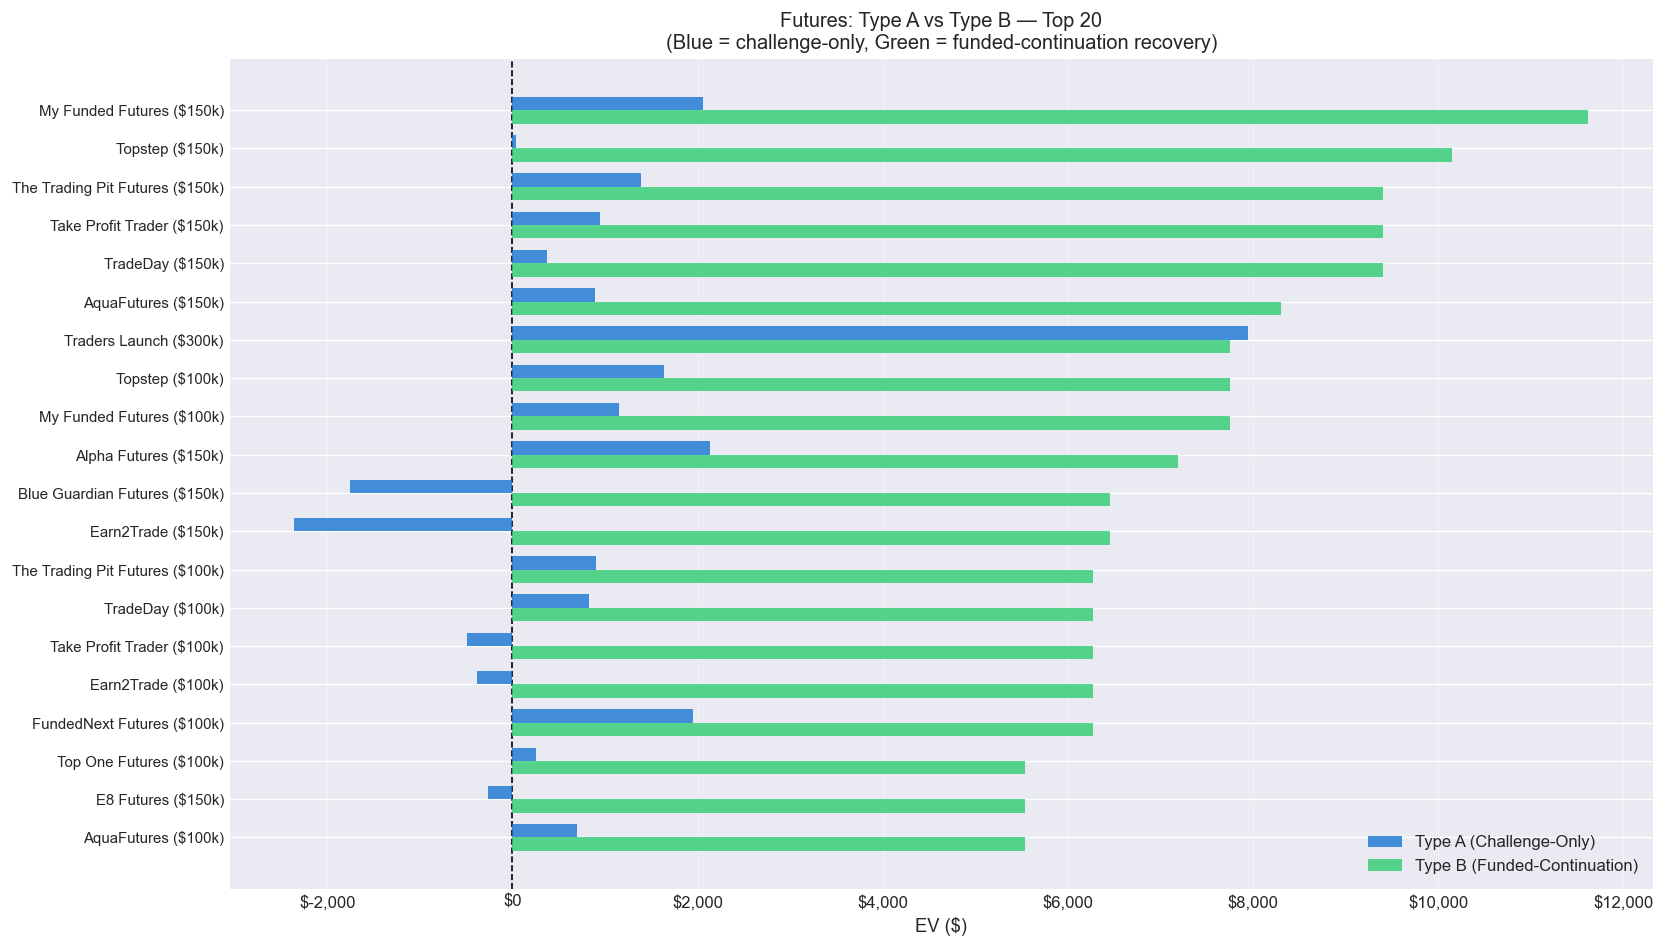

In [5]:
top20 = df_b.nlargest(20, 'ev').sort_values('ev', ascending=True).copy()
top20['label'] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(top20))
h = 0.35

ax.barh(y + h/2, top20['type_a_ev'], h, label='Type A (Challenge-Only)',
        color='#1976d2', alpha=0.8, zorder=3)
ax.barh(y - h/2, top20['ev'], h, label='Type B (Funded-Continuation)',
        color='#2ecc71', alpha=0.8, zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(top20['label'], fontsize=9)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('EV ($)', fontsize=11)
ax.set_title('Futures: Type A vs Type B — Top 20\n'
             '(Blue = challenge-only, Green = funded-continuation recovery)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

In [6]:
best_idx = df_b['ev'].idxmax()
best = results_b[best_idx]

print(f"Challenge: {best['firm']} — ${best['account_size']:,}")
print(f"Challenge cost: ${best['challenge_cost']:,.2f}")
print(f"Payout cap: ${best['payout_cap']:,.0f}")
print(f"Type A EV: ${best['type_a_ev']:,.2f}")
print(f"Type B EV: ${best['ev']:,.2f}")
print(f"Advantage: ${best['ev_advantage']:+,.2f}")
print()

df_cyc = pd.DataFrame(best['cycles'])
df_cyc.style.format({
    'prob_alive': '{:.1%}', 'insured_stack': '${:,.2f}',
    'withdrawal': '${:,.2f}', 'exp_withdrawal': '${:,.2f}',
    'drag': '${:,.2f}', 'exp_drag': '${:,.2f}',
    'prob_fail': '{:.1%}', 'exp_recovery': '${:,.2f}',
    'capital_funded': '${:,.0f}',
}).set_caption(f"Type B Cycle Detail — {best['firm']} ${best['account_size']:,}")

Challenge: My Funded Futures — $150,000.0
Challenge cost: $6,042.33
Payout cap: $100,000
Type A EV: $2,057.67
Type B EV: $11,621.23
Advantage: $+9,563.56



,cycle,prob_alive,insured_stack,withdrawal,exp_withdrawal,drag,exp_drag,prob_fail,exp_recovery,capital_funded
0,1,100.0%,"$6,042.33","$5,400.00","$5,400.00","$2,250.00","$2,250.00",20.0%,"$1,658.47","$12,439"
1,2,80.0%,"$8,292.33","$5,400.00","$4,320.00","$2,250.00","$1,800.00",16.0%,"$1,686.77","$15,814"
2,3,64.0%,"$10,542.33","$5,400.00","$3,456.00","$2,250.00","$1,440.00",12.8%,"$1,637.42","$19,189"
3,4,51.2%,"$12,792.33","$5,400.00","$2,764.80","$2,250.00","$1,152.00",10.2%,"$1,540.33","$22,564"
4,5,41.0%,"$15,042.33","$5,400.00","$2,211.84","$2,250.00",$921.60,8.2%,"$1,416.59","$25,939"
5,6,32.8%,"$17,292.33","$5,400.00","$1,769.47","$2,250.00",$737.28,6.6%,"$1,280.73","$29,314"


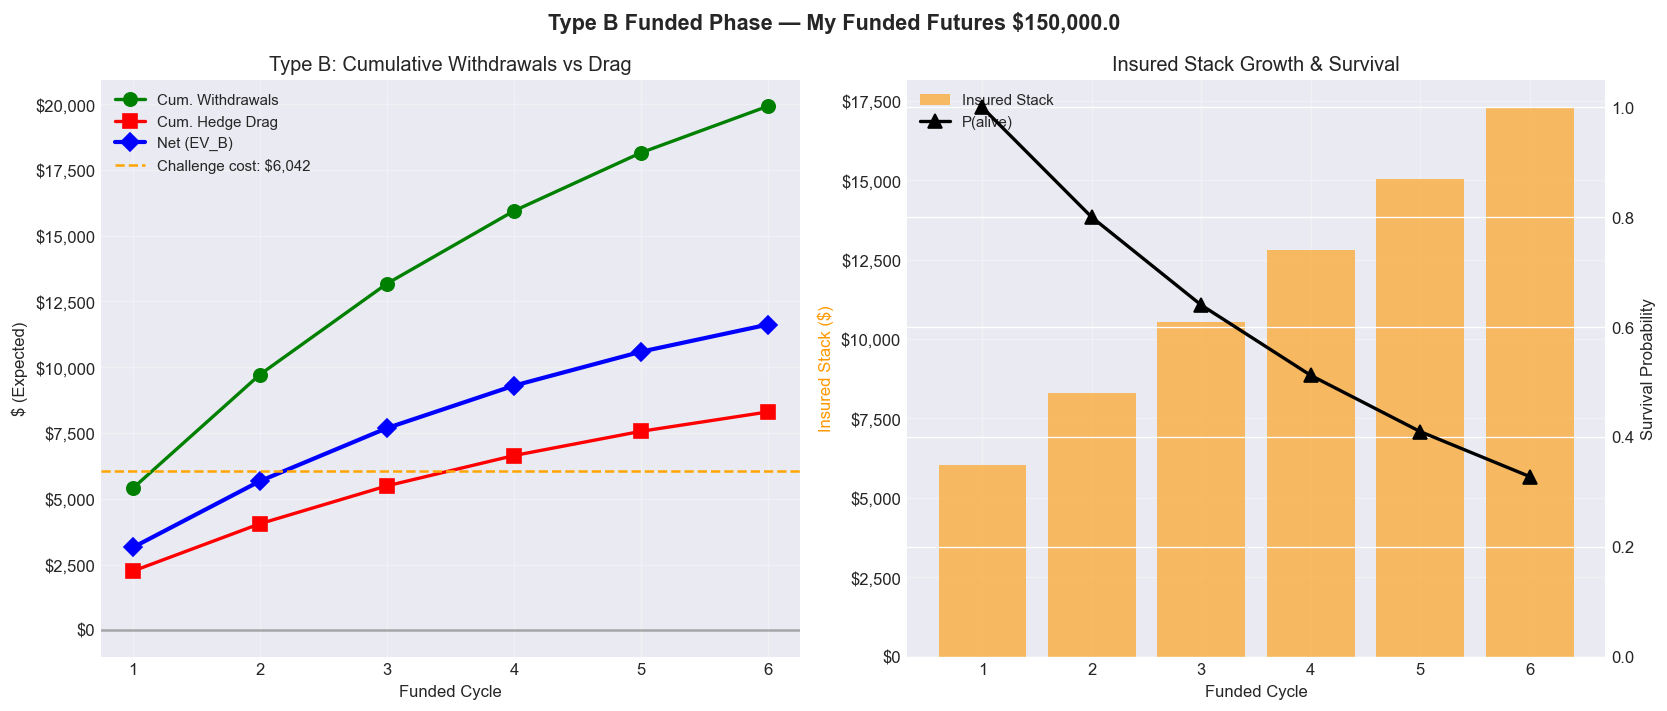

In [7]:
cycles = best['cycles']
cyc_nums = [c['cycle'] for c in cycles]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: cumulative withdrawals vs drag
cum_w = np.cumsum([c['exp_withdrawal'] for c in cycles])
cum_d = np.cumsum([c['exp_drag'] for c in cycles])
cum_net = cum_w - cum_d

ax1.plot(cyc_nums, cum_w, 'g-o', linewidth=2, markersize=8, label='Cum. Withdrawals')
ax1.plot(cyc_nums, cum_d, 'r-s', linewidth=2, markersize=8, label='Cum. Hedge Drag')
ax1.plot(cyc_nums, cum_net, 'b-D', linewidth=2.5, markersize=8, label='Net (EV_B)')
ax1.axhline(y=best['challenge_cost'], color='orange', linestyle='--', linewidth=1.5,
            label=f'Challenge cost: ${best["challenge_cost"]:,.0f}')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.set_xlabel('Funded Cycle'); ax1.set_ylabel('$ (Expected)')
ax1.set_title('Type B: Cumulative Withdrawals vs Drag')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: insured stack & survival
stacks = [c['insured_stack'] for c in cycles]
probs = [c['prob_alive'] for c in cycles]
ax2_twin = ax2.twinx()
ax2.bar(cyc_nums, stacks, alpha=0.6, color='#ff9800', label='Insured Stack', zorder=3)
ax2_twin.plot(cyc_nums, probs, 'k-^', linewidth=2, markersize=8, label='P(alive)')
ax2.set_xlabel('Funded Cycle'); ax2.set_ylabel('Insured Stack ($)', color='#ff9800')
ax2_twin.set_ylabel('Survival Probability'); ax2_twin.set_ylim(0, 1.05)
ax2.set_title('Insured Stack Growth & Survival')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f'Type B Funded Phase — {best["firm"]} ${best["account_size"]:,}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Survival Rate Sensitivity

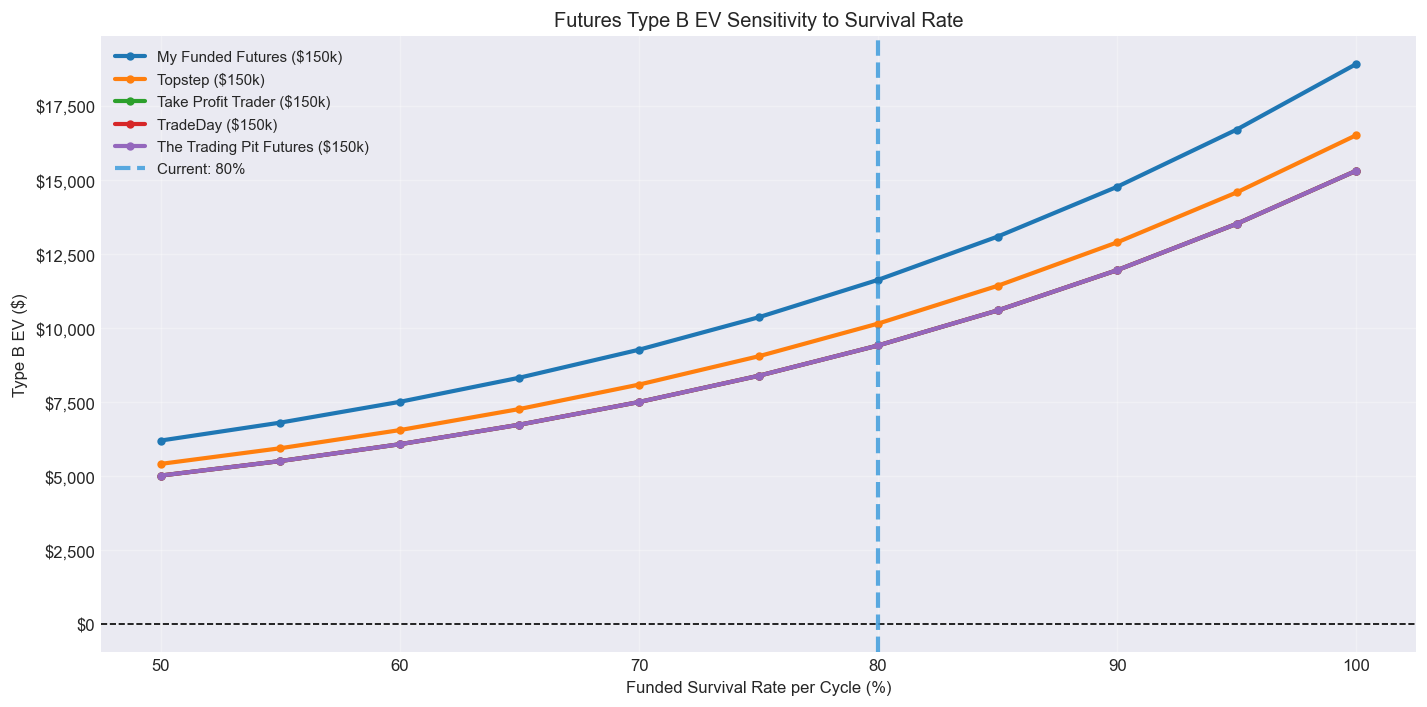

In [8]:
top5 = df_b.nlargest(5, 'ev')[['firm', 'account_size']]
top5_keys = set(zip(top5['firm'], top5['account_size']))
top5_ch = [ch for ch in parsed if (ch['firm'], ch['account_size']) in top5_keys]

survival_sweep = np.arange(0.50, 1.01, 0.05)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = []
    for sr in survival_sweep:
        r = compute_type_b_futures(ch, survival_rate=sr)
        evs.append(r['ev'] if r else 0)
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot(survival_sweep * 100, evs, marker='o', markersize=4,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.axvline(x=FUNDED_SURVIVAL_RATE * 100, color='#3498db', linewidth=2.5,
           linestyle='--', alpha=0.8, label=f'Current: {FUNDED_SURVIVAL_RATE*100:.0f}%')
ax.set_xlabel('Funded Survival Rate per Cycle (%)')
ax.set_ylabel('Type B EV ($)')
ax.set_title('Futures Type B EV Sensitivity to Survival Rate')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — EV Advantage Distribution (Type B − Type A)

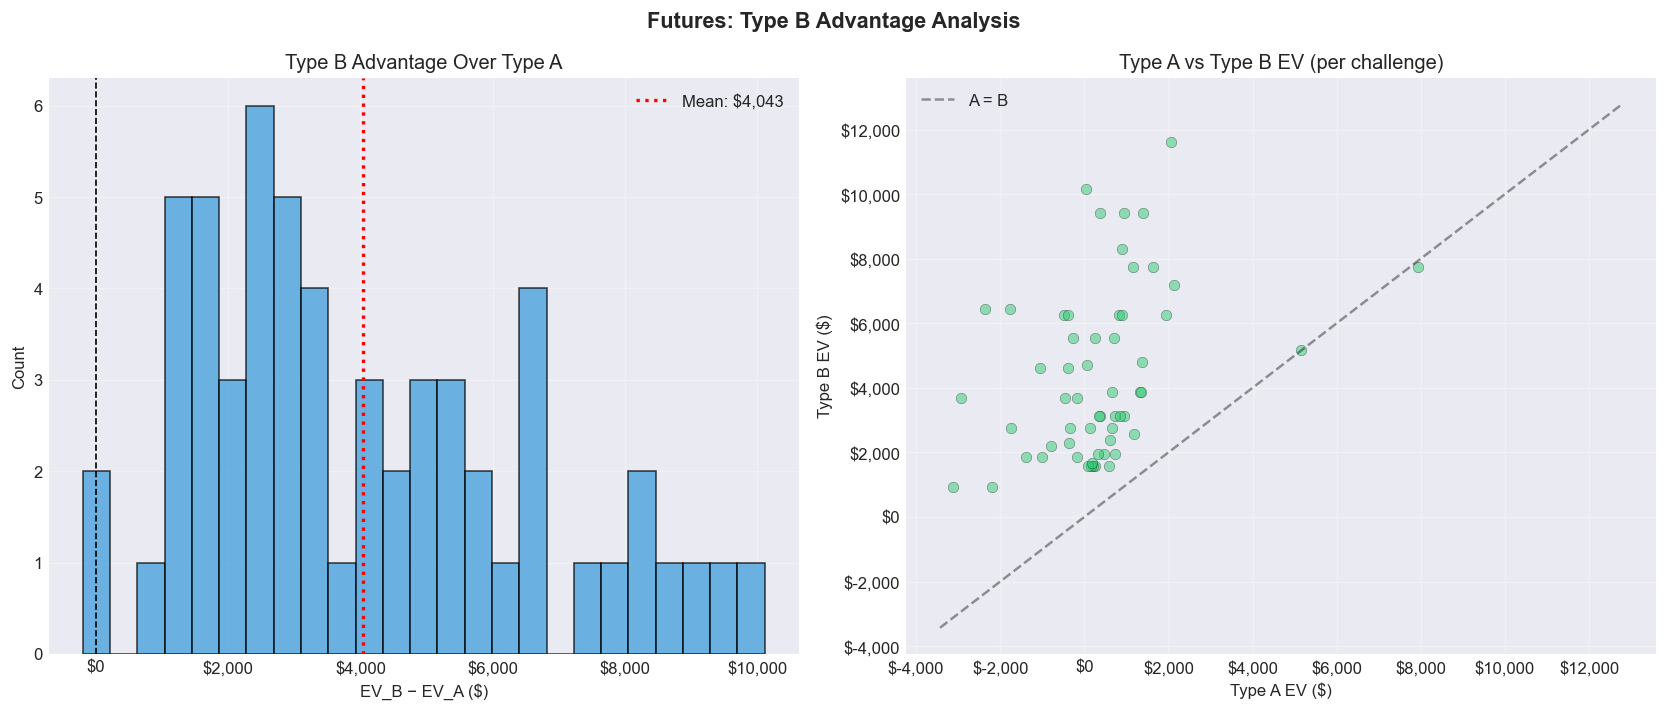

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(df_b['ev_advantage'], bins=25, color='#3498db', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.axvline(x=df_b['ev_advantage'].mean(), color='red', linestyle=':', linewidth=2,
            label=f'Mean: ${df_b["ev_advantage"].mean():,.0f}')
ax1.set_xlabel('EV_B − EV_A ($)'); ax1.set_ylabel('Count')
ax1.set_title('Type B Advantage Over Type A')
ax1.legend()
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

ax2.scatter(df_b['type_a_ev'], df_b['ev'], alpha=0.5, c='#2ecc71',
            edgecolors='black', linewidth=0.3, s=40)
lim_max = max(df_b['type_a_ev'].max(), df_b['ev'].max()) * 1.1
lim_min = min(df_b['type_a_ev'].min(), df_b['ev'].min()) * 1.1
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='A = B')
ax2.set_xlabel('Type A EV ($)'); ax2.set_ylabel('Type B EV ($)')
ax2.set_title('Type A vs Type B EV (per challenge)')
ax2.legend()
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle('Futures: Type B Advantage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 — Type B Futures Summary

### What Type B tells you

- Challenge costs become **recoverable** — not sunk if funded account fails.
- Funded hedge drag is the price of this insurance.
- Payout caps limit withdrawal per cycle, slowing recovery through regular withdrawals.
- But the hedge **still recovers the full stack on failure**, regardless of caps.

### When to use Type B over Type A

- You have capital to maintain a funded hedge
- The challenge cost is significant enough to warrant recovery protection
- You want to treat prop trading as a repeatable system, not a one-shot gamble

### Limitations

- Drag reduces funded-phase profitability
- Recovery requires the funded account to eventually fail (may take many cycles)
- Payout caps mean you're dependent on the hedge mechanism, not just withdrawals

---

**See also:**
- [Type A notebook](type_a_futures_insurance.ipynb) — Challenge-only model
- [Type C notebook](type_c_futures_surplus.ipynb) — Funded surplus model
- [General futures model](futures_hedge_model.ipynb) — All-in-one reference